# 43 — Instance and panoptic segmentation

[Semantic segmentation](./42_semantic_segmentation.ipynb) tells us the class of every pixel, but it merges separate objects of the same class. This notebook adds **instance identity** and then combines instance-aware objects with semantic background regions in **panoptic segmentation**.

We will:

- convert an instance-ID mask into a semantic mask;
- calculate IoU between binary instance masks;
- understand the Mask R-CNN mask head;
- select the relevant class-specific mask for each RoI;
- compose overlapping instance predictions;
- encode semantic and instance identity in a panoptic map;
- calculate the components of Panoptic Quality (PQ).

The examples are deliberately small so each pixel and tensor dimension can be inspected.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

np.set_printoptions(precision=3, suppress=True)
CLASS_NAMES = np.array(["background", "cat", "dog"])
CLASS_COLORS = np.array([
    [235, 235, 235],
    [230, 80, 80],
    [70, 130, 220],
], dtype=np.uint8)
INSTANCE_COLORS = np.array([
    [235, 235, 235],
    [230, 80, 80],
    [255, 170, 60],
    [70, 130, 220],
], dtype=np.uint8)

## 1. Semantic class versus instance identity

A semantic mask stores a **class ID** at each pixel. Every cat pixel has the same value, even if two different cats are visible. An instance mask instead stores a separate **instance ID** for every object. The class of each instance is kept in a small lookup table.

In the example below, instance IDs 1 and 2 are two different cats, while instance ID 3 is a dog. Zero represents background. Mapping instance IDs to their classes deliberately removes object identity:

```text
instance 0 -> background (class 0)
instance 1 -> first cat (class 1)
instance 2 -> second cat (class 1)
instance 3 -> dog (class 2)
```

### Exercise 1 — Convert instance IDs to semantic classes

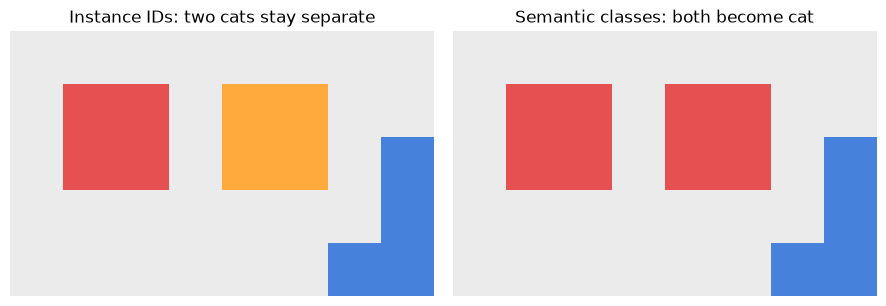

In [6]:
instance_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 2, 2, 0, 0],
    [0, 1, 1, 0, 2, 2, 0, 3],
    [0, 0, 0, 0, 0, 0, 0, 3],
    [0, 0, 0, 0, 0, 0, 3, 3],
], dtype=np.int64)
instance_classes = np.array([0, 1, 1, 2], dtype=np.int64)

# use every instance ID as an index into instance_classes.
semantic_mask = instance_classes[instance_mask] # map 0 to 0, 1 to 1, 2 to 1, and 3 to 2

assert semantic_mask.shape == instance_mask.shape
np.testing.assert_array_equal(np.unique(semantic_mask), [0, 1, 2])
assert semantic_mask[1, 1] == semantic_mask[1, 4] == 1

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(INSTANCE_COLORS[instance_mask])
axes[0].set_title("Instance IDs: two cats stay separate")
axes[1].imshow(CLASS_COLORS[semantic_mask])
axes[1].set_title("Semantic classes: both become cat")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. IoU for instance masks

Detection compares rectangular regions using box IoU. Instance segmentation can compare the actual foreground pixels using **mask IoU**. For two Boolean masks $A$ and $B$,

$$
\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.
$$

The numerator counts pixels belonging to both masks. The denominator counts pixels belonging to either mask, counting their overlap only once.

### Identical boxes can hide different shapes

Consider an X-shaped mask and a plus-shaped mask:

```text
Mask A                 Mask B
1 0 1                  0 1 0
0 1 0                  1 1 1
1 0 1                  0 1 0
```

Both reach every edge of the $3\times3$ grid, so both have the same bounding box and their **box IoU is 1**. However, their masks share only the center pixel. Each mask contains five pixels and their union contains all nine pixels, so

$$
\text{mask IoU}=\frac{1}{5+5-1}=\frac{1}{9}.
$$

Box IoU measures agreement between enclosing rectangles; mask IoU measures agreement between the actual object pixels. It can therefore reveal incorrect shapes and boundaries inside otherwise identical boxes.

### The empty-mask case

For two empty masks, both intersection and union contain zero pixels, giving the undefined expression $0/0$. In instance matching an empty mask does not describe a detected object, so this exercise returns IoU zero rather than treating two empty masks as a perfect match. For semantic metric aggregation, a class absent from both target and prediction is instead often assigned `NaN` and excluded from mean IoU; that is a different use case.

### Exercise 2 — Implement binary mask IoU

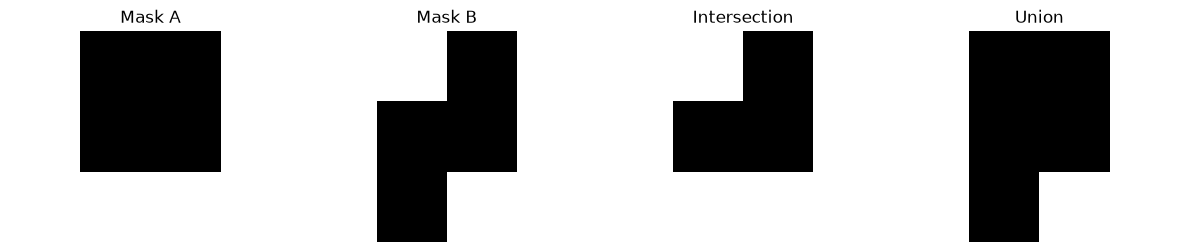

In [10]:
def binary_mask_iou(mask_a, mask_b):
    """Return IoU between two same-shape Boolean masks."""
    if mask_a.shape != mask_b.shape:
        raise ValueError("masks must have the same shape")
    # count the logical intersection and union.
    intersection = mask_a & mask_b
    union = mask_a | mask_b
    # return zero when the union is empty.
    if union.sum() == 0:
        return 0.0
    return intersection.sum() / union.sum()

mask_a = np.array([
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0],
], dtype=bool)
mask_b = np.array([
    [0, 0, 1, 0],
    [0, 1, 1, 0],
    [0, 1, 0, 0],
], dtype=bool)

np.testing.assert_allclose(binary_mask_iou(mask_a, mask_b), 3 / 5)
np.testing.assert_allclose(binary_mask_iou(mask_a, mask_a), 1.0)
np.testing.assert_allclose(
    binary_mask_iou(np.zeros((2, 2), bool), np.zeros((2, 2), bool)), 0.0
)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for axis, image, title in zip(
    axes,
    [mask_a, mask_b, mask_a & mask_b, mask_a | mask_b],
    ["Mask A", "Mask B", "Intersection", "Union"],
):
    axis.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

## 3. From Faster R-CNN to Mask R-CNN

Mask R-CNN extends the two-stage Faster R-CNN pipeline. The Region Proposal Network (RPN) first proposes rectangular regions that might contain objects. At this point a proposal is only a candidate region: its final class, precise box, and pixel shape are not known yet.

The proposals can have different sizes, but later network heads require fixed-size tensors. **RoI Align** samples each proposal from the shared backbone feature map and produces one fixed-size feature tensor per proposal. If there are $R$ proposals, we now have $R$ separate RoI feature tensors. The same RoI features are sent to three parallel heads:

1. the **class head** predicts what object the RoI contains, or background;
2. the **box head** predicts corrections that make the proposal box fit the object more precisely;
3. the **mask head** predicts which pixels *inside that RoI* belong to the object.

```text
image -> backbone -> RPN -> RoI Align -> class head
                                      +-> box head
                                      +-> mask head
```

These are different questions about the same candidate. For example, the class head may answer `cat`, the box head may move the left boundary slightly, and the mask head may describe the cat's non-rectangular silhouette inside the corrected box. The mask head does not predict a complete image-sized mask. It predicts in an **RoI-local coordinate system**, commonly at a fixed resolution such as $28\times28$. At inference, that small mask is resized to the detected box and placed at the box's location on the image.

RoI Align preserves fractional sampling locations instead of rounding proposal boundaries to coarse feature-map cells. This matters more for masks than for class labels: shifting a feature by even one cell may move the predicted object boundary by several image pixels.

### Class head versus mask head

The class head produces one score vector per RoI. With $C$ foreground classes, it commonly has shape $(R,C+1)$ because background is also a class. After softmax, one label is selected for the complete RoI. It answers: **what object is in this region?**

The mask head instead produces a small spatial grid for every possible foreground class, commonly with shape $(R,C,M,M)$:

- $R$: number of RoIs;
- $C$: number of foreground classes;
- $M,M$: height and width of each small mask.

Why predict $C$ candidate masks? Different classes have different characteristic shapes, so each class channel can learn its own foreground-mask behavior. The model does **not** keep all $C$ masks for one RoI. It first uses the RoI's known class to select exactly one channel:

```text
RoI 0 predicted as dog -> select the dog mask channel
RoI 1 predicted as cat -> select the cat mask channel
```

During training, the ground-truth RoI class selects the channel whose mask loss is calculated. During inference, the class predicted by the class head selects it. Background proposals do not need an object mask.

### Why sigmoid rather than softmax?

Once the appropriate class channel is selected, every one of its $M\times M$ positions asks an independent binary question: **does this position belong to this object instance?** A sigmoid converts each mask logit into a foreground probability between zero and one. A threshold such as 0.5 then produces a Boolean mask.

Softmax is suitable for the class head because the RoI chooses among mutually exclusive labels such as cat, dog, or background. It is not used across mask channels because mask prediction is not asking every pixel to choose among all object classes again; the class decision has already selected the relevant channel.

### Shape example used below

Exercise 3 uses $R=2$ RoIs, $C=2$ foreground classes (`cat` and `dog`), and $M=2$. Therefore `mask_logits` has shape $(2,2,2,2)$. For RoI 0, which is a dog, we select `mask_logits[0, 1]`. For RoI 1, which is a cat, we select `mask_logits[1, 0]`. Stacking those selections removes the class axis and produces `selected_logits` with shape $(R,M,M)=(2,2,2)$.

### Exercise 3 — Select one class-specific mask per RoI

In [17]:
mask_logits = np.array([
    [
        [[-2, -2], [-2, -2]],  # RoI 0, cat channel
        [[ 3,  3], [-1,  2]],  # RoI 0, dog channel
    ],
    [
        [[ 2, -1], [ 2,  2]],  # RoI 1, cat channel
        [[-3, -3], [-3, -3]],  # RoI 1, dog channel
    ],
], dtype=float)

# imagine that is the result of class head for two RoIs: RoI 0 is a dog, RoI 1 is a cat.
roi_class_ids = np.array([1, 0])  # RoI 0 is dog; RoI 1 is cat.

# select mask_logits[r, roi_class_ids[r]] for every RoI r.
selected_logits = mask_logits[np.arange(len(roi_class_ids)), roi_class_ids]
# apply sigmoid and classify probabilities >= 0.5 as foreground.
selected_probabilities = 1 / (1 + np.exp(-selected_logits))
selected_masks = selected_probabilities >= 0.5

assert selected_logits.shape == (2, 2, 2)
np.testing.assert_array_equal(
    selected_masks,
    [[[True, True], [False, True]], [[True, False], [True, True]]],
)
selected_probabilities, selected_masks

(array([[[0.953, 0.953],
         [0.269, 0.881]],
 
        [[0.881, 0.269],
         [0.881, 0.881]]]),
 array([[[ True,  True],
         [False,  True]],
 
        [[ True, False],
         [ True,  True]]]))

## 4. Composing instance predictions

A detector returns separate masks, scores, and classes rather than one final integer canvas. Predicted masks can overlap. A simple visualization policy is to process predictions from highest to lowest score and let each prediction claim only pixels that are still unassigned. This ensures a lower-scoring mask cannot overwrite a higher-scoring one.

This is only a composition rule for this exercise. Real systems may resolve overlaps using mask probabilities, class scores, or task-specific post-processing. The instance map stores `0` for unassigned background and `prediction_index + 1` for a claimed object.

### Exercise 4 — Let high-confidence instances claim pixels first

In [22]:
scores = np.array([0.95, 0.70, 0.85])
scores.argsort(), scores.argsort()[::-1]

(array([1, 2, 0]), array([0, 2, 1]))

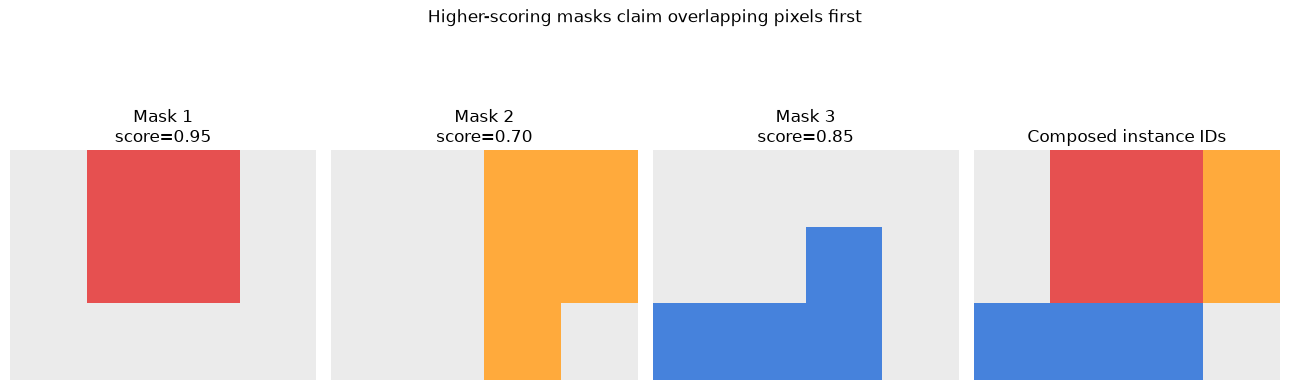

In [33]:
def compose_instance_map(masks, scores):
    """Compose (K, H, W) Boolean masks in descending score order."""
    if masks.ndim != 3 or scores.shape != (masks.shape[0],):
        raise ValueError("masks and scores have incompatible shapes")
    instance_map = np.zeros(masks.shape[1:], dtype=np.int64)
    # obtain prediction indexes from greatest score to smallest.
    order = scores.argsort()[::-1]
    for prediction_index in order:
        # claim pixels inside this mask only where instance_map is zero.
        claim = masks[prediction_index] & (instance_map == 0)
        instance_map[claim] = prediction_index + 1
    return instance_map

overlapping_masks = np.array([
    [[0, 1, 1, 0], [0, 1, 1, 0], [0, 0, 0, 0]],
    [[0, 0, 1, 1], [0, 0, 1, 1], [0, 0, 1, 0]],
    [[0, 0, 0, 0], [0, 0, 1, 0], [1, 1, 1, 0]],
], dtype=bool)
prediction_scores = np.array([0.95, 0.70, 0.85])
composed = compose_instance_map(overlapping_masks, prediction_scores)

np.testing.assert_array_equal(
    composed, [[0, 1, 1, 2], [0, 1, 1, 2], [3, 3, 3, 0]]
)
fig, axes = plt.subplots(1, 4, figsize=(13, 5))
for prediction_index, axis in enumerate(axes[:3]):
    mask_cmap = ListedColormap(
        np.stack([CLASS_COLORS[0], INSTANCE_COLORS[prediction_index + 1]]) / 255
    )
    axis.imshow(
        overlapping_masks[prediction_index],
        cmap=mask_cmap, vmin=0, vmax=1, interpolation="nearest",
    )
    axis.set_title(
        f"Mask {prediction_index + 1}\nscore={prediction_scores[prediction_index]:.2f}"
    )

axes[3].imshow(
    composed,
    cmap=ListedColormap(INSTANCE_COLORS / 255),
    vmin=0, vmax=3, interpolation="nearest",
)
axes[3].set_title("Composed instance IDs")
for axis in axes:
    axis.axis("off")
fig.suptitle("Higher-scoring masks claim overlapping pixels first")
plt.tight_layout()
plt.show()

## 5. Panoptic segmentation: things and stuff together

Panoptic segmentation gives every pixel one semantic class while also distinguishing separate instances of countable **thing** classes such as people, cars, cats, and dogs. Amorphous **stuff** classes such as sky, road, grass, or water receive a semantic region label but are not normally counted as individual object instances.

A panoptic output can be stored as one segment ID per pixel plus metadata describing each segment's semantic class and whether it is a thing. For a compact numerical exercise, we encode

$$
\text{segment ID}=\text{class ID}\times D+\text{instance ID},
$$

where $D$ is larger than every possible instance ID. Stuff uses instance ID zero. This arithmetic convention is illustrative; real datasets provide their own ID formats and metadata.

### Exercise 5 — Encode and decode panoptic IDs

In [36]:
semantic_ids = np.array([
    [3, 3, 3, 3, 3],  # sky: stuff class 3
    [3, 1, 1, 3, 2],  # cat 1 and dog 1
    [4, 1, 1, 4, 2],  # road: stuff class 4
    [4, 4, 4, 1, 1],  # a second cat
], dtype=np.int64)
instance_ids = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1],
    [0, 1, 1, 0, 1],
    [0, 0, 0, 2, 2],
], dtype=np.int64)
divisor = 1000

# encode the two maps in one panoptic segment-ID map.
panoptic_ids = semantic_ids * divisor + instance_ids
# recover class IDs with integer division and instance IDs with remainder.
decoded_classes = panoptic_ids // divisor
decoded_instances = panoptic_ids % divisor

np.testing.assert_array_equal(decoded_classes, semantic_ids)
np.testing.assert_array_equal(decoded_instances, instance_ids)
assert panoptic_ids[0, 0] == 3000  # sky, no instance identity
assert panoptic_ids[1, 1] == 1001  # cat instance 1
assert panoptic_ids[3, 3] == 1002  # cat instance 2
panoptic_ids

array([[3000, 3000, 3000, 3000, 3000],
       [3000, 1001, 1001, 3000, 2001],
       [4000, 1001, 1001, 4000, 2001],
       [4000, 4000, 4000, 1002, 1002]])

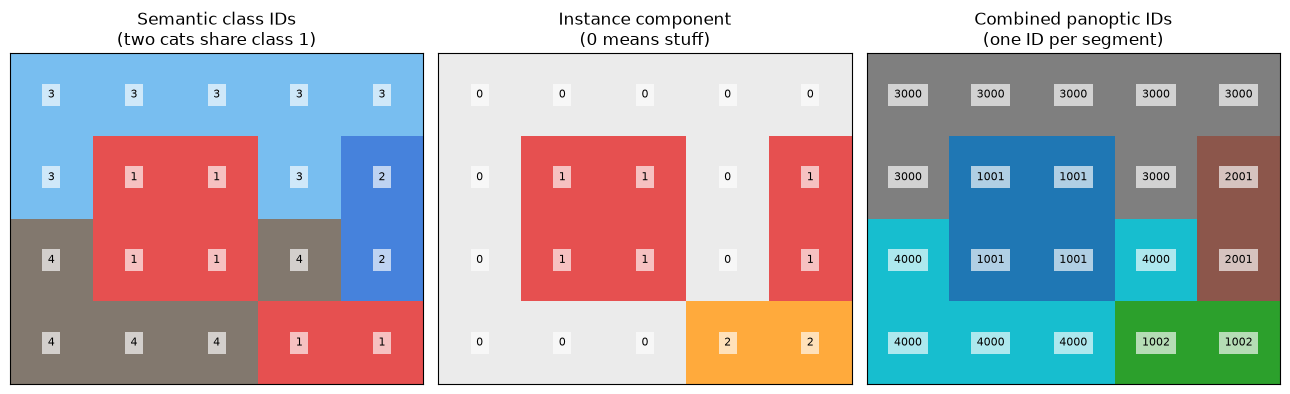

In [38]:
# Give semantic classes stable colors: background, cat, dog, sky, and road.
semantic_colors = np.array([
    [235, 235, 235],
    [230, 80, 80],
    [70, 130, 220],
    [120, 190, 240],
    [130, 120, 110],
], dtype=np.uint8)

# Convert large segment IDs to consecutive color indexes only for display.
segment_values, compact_panoptic = np.unique(panoptic_ids, return_inverse=True)
compact_panoptic = compact_panoptic.reshape(panoptic_ids.shape)
panoptic_colors = plt.colormaps["tab10"].resampled(len(segment_values))

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].imshow(semantic_colors[semantic_ids])
axes[0].set_title("Semantic class IDs\n(two cats share class 1)")
axes[1].imshow(
    instance_ids, cmap=ListedColormap(INSTANCE_COLORS[:3] / 255),
    vmin=0, vmax=2, interpolation="nearest",
)
axes[1].set_title("Instance component\n(0 means stuff)")
axes[2].imshow(compact_panoptic, cmap=panoptic_colors, interpolation="nearest")
axes[2].set_title("Combined panoptic IDs\n(one ID per segment)")

display_values = [semantic_ids, instance_ids, panoptic_ids]
for axis, values in zip(axes, display_values):
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            axis.text(
                column, row, str(values[row, column]), ha="center", va="center",
                fontsize=8, bbox={"facecolor": "white", "alpha": 0.65, "edgecolor": "none"},
            )
    axis.set_xticks([])
    axis.set_yticks([])

plt.tight_layout()
plt.show()

## 6. Panoptic Quality

Pixel accuracy does not test whether separate instances were found correctly. Panoptic Quality evaluates matched predicted and ground-truth segments. After one-to-one matching of same-class segments above an IoU threshold, let $TP$ be the matched pairs, $FP$ the unmatched predictions, and $FN$ the unmatched ground-truth segments.

$$
PQ=\frac{\sum_{(p,g)\in TP}\mathrm{IoU}(p,g)}{|TP|+0.5|FP|+0.5|FN|}.
$$

The same expression can be separated into:

$$
SQ=\frac{\sum_{(p,g)\in TP}\mathrm{IoU}(p,g)}{|TP|},
\qquad
RQ=\frac{|TP|}{|TP|+0.5|FP|+0.5|FN|},
\qquad PQ=SQ\times RQ.
$$

$SQ$ is **segmentation quality**: how well matched shapes overlap. $RQ$ is **recognition quality**: how successfully segments were found without misses or extras. Thus a method can have accurate masks for its matched objects but still have low PQ because it misses many objects.

### Exercise 6 — Separate mask quality from recognition quality

In [41]:
def panoptic_quality(matched_ious, false_positives, false_negatives):
    """Return segmentation quality, recognition quality, and PQ."""
    matched_ious = np.asarray(matched_ious, dtype=float)
    true_positives = matched_ious.size
    # calculate SQ as mean matched IoU. Use 0 when there are no matches.
    segmentation_quality = np.sum(matched_ious) / true_positives if true_positives > 0 else 0.0
    # calculate the denominator shared by RQ and PQ.
    denominator = true_positives + 0.5*false_positives + 0.5*false_negatives
    recognition_quality = true_positives / denominator if denominator > 0 else 0.0
    # combine SQ and RQ.
    pq = segmentation_quality * recognition_quality
    return segmentation_quality, recognition_quality, pq

matched_ious = np.array([0.80, 0.70, 0.60])
sq, rq, pq = panoptic_quality(matched_ious, false_positives=1, false_negatives=2)
np.testing.assert_allclose(sq, 0.70)
np.testing.assert_allclose(rq, 2 / 3)
np.testing.assert_allclose(pq, 7 / 15)
print(f"SQ={sq:.3f}, RQ={rq:.3f}, PQ={pq:.3f}")

SQ=0.700, RQ=0.667, PQ=0.467


## 7. Putting the tasks side by side

| Task | Pixel classes | Separate same-class objects | Typical representation |
| --- | --- | --- | --- |
| Semantic segmentation | Yes | No | One class-ID map |
| Instance segmentation | For detected object instances | Yes | A set of masks, classes, and scores |
| Panoptic segmentation | Yes, for the complete image | Yes for things | One non-overlapping segment map plus metadata |

Instance segmentation generally leaves pixels outside detected objects as background. Panoptic segmentation aims to assign every pixel to exactly one non-overlapping segment, covering both things and stuff. Two predicted instance masks may initially overlap, but a final panoptic output must resolve that conflict.

## Reflection

Answer briefly in your own words.

1. What information is lost when an instance mask is converted to a semantic mask?
2. How does mask IoU differ from box IoU?
3. What three outputs are predicted from RoI features in Mask R-CNN?
4. Why is RoI Align particularly helpful for mask prediction?
5. Why does the mask head produce one channel per foreground class?
6. Why do the class-specific mask channels use sigmoid rather than competing with softmax?
7. What is the difference between thing and stuff classes?
8. Why must final panoptic segments not overlap?
9. What different failure types do SQ and RQ reveal?
10. Can a model have high SQ but modest PQ? Explain.

### Answers

1. Separate object identity is lost: different instances of the same class receive the same semantic class ID.
2. Box IoU compares enclosing rectangles, while mask IoU compares the actual foreground pixels and therefore measures shape and boundary agreement.
3. The heads predict an object class, refined box coordinates, and an RoI-local foreground mask.
4. RoI Align avoids coarse coordinate rounding, so extracted features stay better aligned with the object's pixel boundaries.
5. A separate channel lets the model learn class-specific shapes; only the channel selected by the RoI's class is trained or used.
6. Each selected mask pixel independently answers foreground or background for one instance. It does not need to compete against other classes.
7. Things are countable object instances such as cats or cars. Stuff describes amorphous regions such as sky, road, or grass.
8. Panoptic segmentation assigns exactly one segment identity to every pixel, so overlapping predictions must be resolved.
9. SQ measures the mask overlap of matched segments; RQ penalizes missed ground-truth segments and unmatched predictions.
10. Yes. Its matched masks can overlap their targets accurately, giving high SQ, while many missed or extra segments lower RQ and therefore PQ.